# Word-Level LSTM Text Generator

This notebook demonstrates how to create a word-level LSTM text generator using a book as the dataset. We will download a book, preprocess the text, build and train an LSTM model, and finally generate text based on the trained model.

In [1]:
import requests
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

def download_book(url):
    response = requests.get(url)
    if response.status_code == 200:
        return response.text
    else:
        raise Exception('Failed to download the book.')

In [2]:

book_url = 'https://www.gutenberg.org/files/11/11-0.txt'  # Alice's Adventures in Wonderland
book_text = download_book(book_url)
print(book_text[:500])  # Print the first 500 characters of the book

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The


In [3]:
def preprocess_text(text):
    text = text.lower()
    text = text.replace('\n', ' ')
    return text

processed_text = preprocess_text(book_text)
print(processed_text[:500])  # Print the first 500 characters of the processed text

*** start of the project gutenberg ebook 11 ***  [illustration]     alice’s adventures in wonderland  by lewis carroll  the millennium fulcrum edition 3.0  contents   chapter i.     down the rabbit-hole  chapter ii.    the pool of tears  chapter iii.   a caucus-race and a long tale  chapter iv.    the rabbit sends in a little bill  chapter v.     advice from a caterpillar  chapter vi.    pig and pepper  chapter vii.   a mad tea-party  chapter viii.  the queen’s croquet-ground  chapter ix.    the


In [5]:
def create_sequences(text, seq_length):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts([text])
    total_words = len(tokenizer.word_index) + 1
    input_sequences = []
    words = text.split()
    for i in range(seq_length, len(words)):
        seq = words[i-seq_length:i+1]  # seq_length input + 1 output
        input_sequences.append(' '.join(seq))
    input_sequences = tokenizer.texts_to_sequences(input_sequences)
    input_sequences = pad_sequences(input_sequences, maxlen=seq_length+1, padding='pre')
    return input_sequences, total_words, tokenizer

seq_length = 10
input_sequences, total_words, tokenizer = create_sequences(processed_text, seq_length)
print(input_sequences[:5])  # Print the first 5 input sequences

[[   0    0 1598    7    1 1134 1135 1136 1137 1599  288]
 [   0 1598    7    1 1134 1135 1136 1137 1599  288  562]
 [   0    7    1 1134 1135 1136 1137 1599  288  562   11]
 [   0    1 1134 1135 1136 1137 1599  288  562   11  876]
 [   0 1134 1135 1136 1137 1599  288  562   11  876   70]]


In [ ]:
def prepare_data(input_sequences):
    X, y = input_sequences[:, :-1], input_sequences[:, -1]
    y = tf.keras.utils.to_categorical(y, num_classes=total_words)
    # return X, y

X, y = prepare_data(input_sequences)
print(X.shape, y.shape)  # Print the shapes of X and y

(26533, 10) (26533, 3067)


In [8]:
def build_model(total_words, seq_length):
    model = Sequential()
    model.add(Embedding(total_words, 100, input_length=seq_length))
    model.add(LSTM(150, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(150))
    model.add(Dropout(0.2))
    model.add(Dense(total_words, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

model = build_model(total_words, seq_length)
model.summary()  # Print the model summary

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.0519 - loss: 6.4840
Epoch 2/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.0649 - loss: 5.8982
Epoch 3/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.0811 - loss: 5.6845
Epoch 4/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.1041 - loss: 5.4006
Epoch 5/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.1202 - loss: 5.1980
Epoch 6/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.1271 - loss: 5.0588
Epoch 7/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.1396 - loss: 4.9130
Epoch 8/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.1562 - loss: 4.7420
Epoch 9/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.1716 - loss: 4.5606
Epoch 10/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.1778 - loss: 4.4208
Epoch 11/100
830/830 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.1856 - loss: 4.2731
Epoch 12/100
830/83

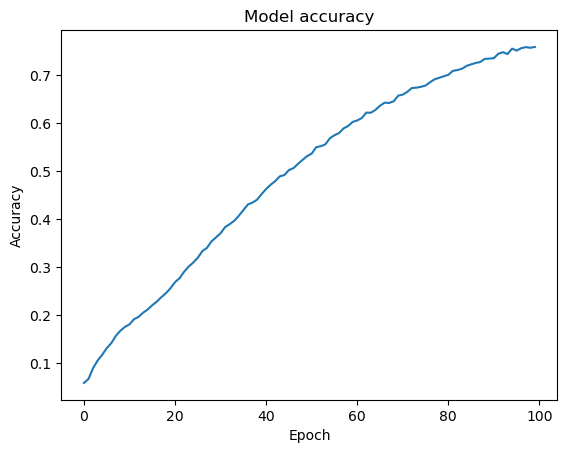

In [9]:
history = model.fit(X, y, epochs=100, verbose=1)
plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

In [11]:
def generate_text(model, tokenizer, seq_length, seed_text, num_words):
    output_text = seed_text
    for _ in range(num_words):
        input_seq = tokenizer.texts_to_sequences([output_text])[0]
        input_seq = pad_sequences([input_seq], maxlen=seq_length, padding='pre')
        predicted_word_index = np.argmax(model.predict(input_seq, verbose=0), axis=-1)
        output_word = tokenizer.index_word[predicted_word_index[0]]
        output_text += ' ' + output_word
    return output_text

seed_text = 'alice was'
generated_text = generate_text(model, tokenizer, seq_length, seed_text, 50)
print(generated_text)  # Print the generated text

alice was reading off the cake but the three gardeners instantly left to pieces and the players took a little house and then not a very difficult game indeed the moment she had to stoop to save the meaning but she felt that the fan and gloves for very neatly and then
